In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

In [3]:
X = data.data
y= data.target

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=45)

In [5]:
from sklearn.linear_model import LinearRegression
L = LinearRegression()

In [6]:
L.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_pred = L.predict(X_test)

In [8]:
from sklearn.metrics import r2_score , mean_squared_error

print("R2 Score", r2_score(y_test,y_pred))
print("MSE Score", np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score 0.5188113124539249
MSE Score 48.72713760953253


In [9]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.0001)

In [10]:
R.fit(X_train,y_train)

,alpha,0.0001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [11]:
y_pred1 = R.predict(X_test)

In [12]:
print("R2 Score", r2_score(y_test,y_pred1))
print("MSE Score", np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 Score 0.5189732635884954
MSE Score 48.71893700181954


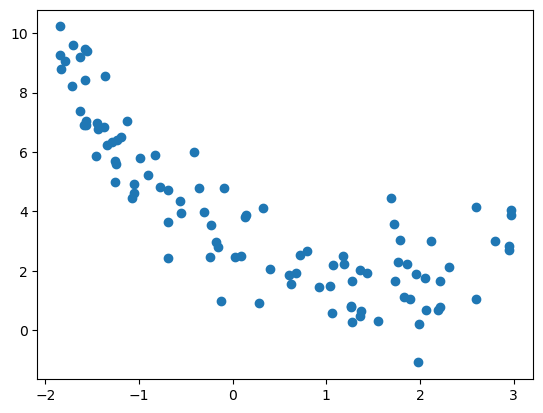

In [13]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

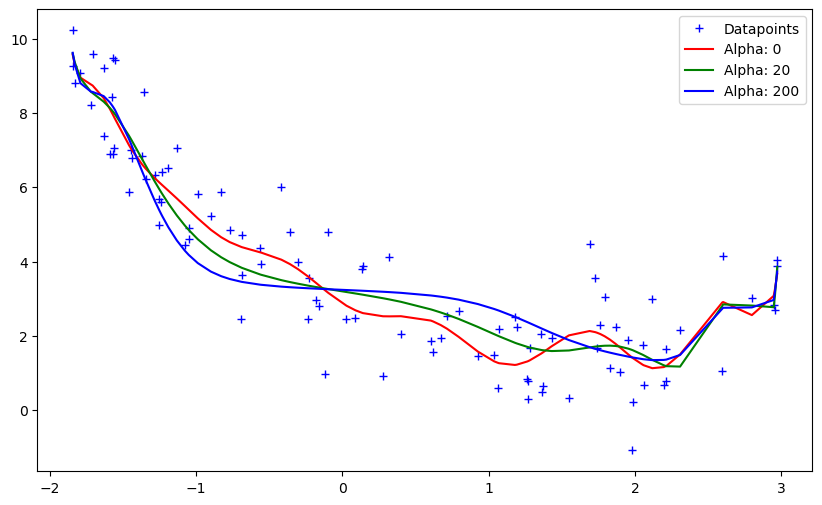

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()